In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tqdm import tqdm
from sklearn.manifold import TSNE
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
BATCH_SIZE = 128

cifar_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), 
    transforms.Resize((28, 28)),                 
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))        
])

mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [3]:
print("Veri setleri (28x28 Grayscale - Adil Karşılaştırma) hazırlanıyor...")
train_cifar = datasets.CIFAR10(root='./data', train=True, download=True, transform=cifar_transform)
test_cifar = datasets.CIFAR10(root='./data', train=False, download=True, transform=cifar_transform)

train_mnist = datasets.MNIST(root='./data', train=True, download=True, transform=mnist_transform)
test_mnist = datasets.MNIST(root='./data', train=False, download=True, transform=mnist_transform)

combined_train_dataset = ConcatDataset([train_cifar, train_mnist])
train_loader = DataLoader(combined_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

test_loader_cifar = DataLoader(test_cifar, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader_mnist = DataLoader(test_mnist, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Veri setleri (28x28 Grayscale - Adil Karşılaştırma) hazırlanıyor...
Files already downloaded and verified
Files already downloaded and verified


In [4]:
class GatedActivation(nn.Module):
    def __init__(self, channels):
        super(GatedActivation, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.gate_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, channels // 2),
            nn.ReLU(),
            nn.Linear(channels // 2, channels),
            nn.Sigmoid() 
        )
        self.saved_mask = None 

    def forward(self, x):
        context = self.avg_pool(x)
        mask = self.gate_fc(context).unsqueeze(2).unsqueeze(3)
        if not self.training:
            self.saved_mask = mask.detach().cpu()
        return x * mask  

In [5]:
class GatedCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(GatedCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1) 
        self.bn1 = nn.BatchNorm2d(32)
        self.gate1 = GatedActivation(32) 
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.gate2 = GatedActivation(64)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout2d(p=0.25)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.gate3 = GatedActivation(128)
        
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        self.gate4 = GatedActivation(128)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.dropout2 = nn.Dropout2d(p=0.25)

        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(256)
        self.gate5 = GatedActivation(256)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.dropout3 = nn.Dropout2d(p=0.25)

        self.flatten_dim = 256 * 3 * 3 
        
        self.fc1 = nn.Linear(self.flatten_dim, 1024)
        self.bn_fc1 = nn.BatchNorm1d(1024)
        self.fc2 = nn.Linear(1024, 512)
        self.bn_fc2 = nn.BatchNorm1d(512)
        self.fc3 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.gate1(self.bn1(self.conv1(x)))
        x = self.gate2(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        x = self.dropout1(x)

        x = self.gate3(self.bn3(self.conv3(x)))
        x = self.gate4(self.bn4(self.conv4(x)))
        x = self.pool2(x)
        x = self.dropout2(x)

        x = self.gate5(self.bn5(self.conv5(x)))
        x = self.pool3(x)
        x = self.dropout3(x)

        x = x.view(-1, self.flatten_dim)
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(self.bn_fc2(self.fc2(x)))
        x = F.dropout(x, p=0.5, training=self.training)
        
        x = self.fc3(x)
        return x


In [6]:
model = GatedCNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

In [7]:
def evaluate_domain(model, loader, domain_name):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            loss = criterion(outputs, target)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(target.cpu().numpy())
            
    acc = 100 * correct / total
    avg_loss = running_loss / len(loader)
    return avg_loss, acc, all_labels, all_preds

In [8]:
def train_and_analyze(epochs=15):
    print(f"Eğitim Başlıyor ({epochs} Epoch)...")
    history = {
        'train_loss': [], 
        'train_acc': [],    
        'val_acc_mnist': [], 
        'val_acc_cifar': []
    }
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        
        for data, target in pbar:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, target)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total_train += target.size(0)
            correct_train += (predicted == target).sum().item()
            
            pbar.set_postfix({'Loss': loss.item()})
            
        epoch_loss = running_loss / len(train_loader)
        epoch_train_acc = 100 * correct_train / total_train
        
        _, val_acc_m, _, _ = evaluate_domain(model, test_loader_mnist, "MNIST")
        _, val_acc_c, _, _ = evaluate_domain(model, test_loader_cifar, "CIFAR")
        
        print(f"   -> Train Acc: %{epoch_train_acc:.2f} | MNIST Val: %{val_acc_m:.2f} | CIFAR Val: %{val_acc_c:.2f}")
        
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc_mnist'].append(val_acc_m)
        history['val_acc_cifar'].append(val_acc_c)
        
        scheduler.step(epoch_loss)
        
    return history


In [9]:
history = train_and_analyze(epochs=10)

Eğitim Başlıyor (10 Epoch)...


Epoch 1/10: 100%|██████████| 860/860 [00:36<00:00, 23.27it/s, Loss=0.766]


   -> Train Acc: %69.08 | MNIST Val: %98.70 | CIFAR Val: %52.19


Epoch 2/10: 100%|██████████| 860/860 [00:41<00:00, 20.83it/s, Loss=0.56] 


   -> Train Acc: %77.18 | MNIST Val: %99.17 | CIFAR Val: %60.97


...

   -> Train Acc: %84.03 | MNIST Val: %99.42 | CIFAR Val: %71.14


Epoch 9/10: 100%|██████████| 860/860 [00:36<00:00, 23.51it/s, Loss=0.693]


   -> Train Acc: %84.48 | MNIST Val: %99.42 | CIFAR Val: %71.44


Epoch 10/10: 100%|██████████| 860/860 [00:36<00:00, 23.76it/s, Loss=0.348]


   -> Train Acc: %84.84 | MNIST Val: %99.44 | CIFAR Val: %71.88


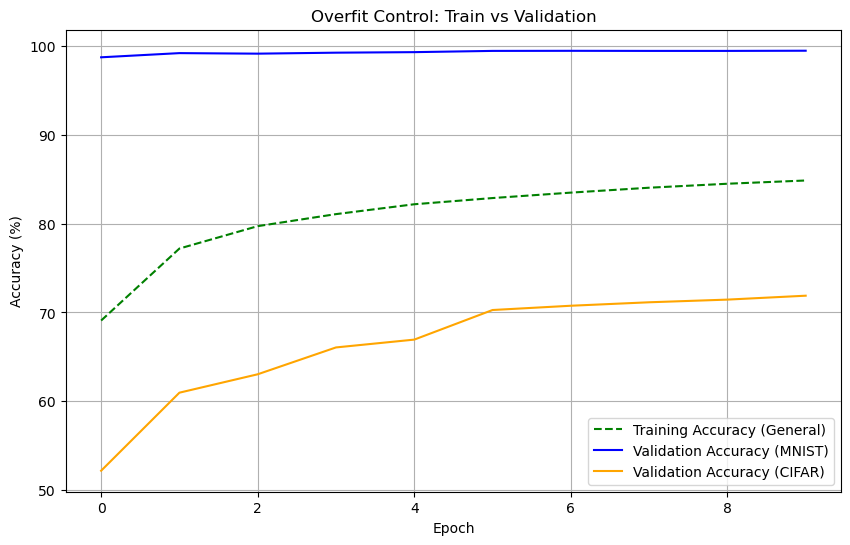

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(history['train_acc'], label='Training Accuracy (General)', color='green', linestyle='--')
plt.plot(history['val_acc_mnist'], label='Validation Accuracy (MNIST)', color='blue')
plt.plot(history['val_acc_cifar'], label='Validation Accuracy (CIFAR)', color='orange')

plt.title('Overfit Control: Train vs Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
def analyze_gate_behavior(model, loader_mnist, loader_cifar):
    model.eval()
    mask_values_mnist = []
    mask_values_cifar = []
    
    with torch.no_grad():
        for i, (data, _) in enumerate(loader_mnist):
            if i >= 10: break
            data = data.to(device)
            _ = model(data)
            mask_vals = model.gate1.saved_mask.mean(dim=(1, 2, 3)).cpu().numpy() 
            mask_values_mnist.extend(mask_vals)

    with torch.no_grad():
        for i, (data, _) in enumerate(loader_cifar):
            if i >= 10: break
            data = data.to(device)
            _ = model(data)
            mask_vals = model.gate1.saved_mask.mean(dim=(1, 2, 3)).cpu().numpy()
            mask_values_cifar.extend(mask_vals)
            
    plt.figure(figsize=(10, 6))
    sns.kdeplot(mask_values_mnist, fill=True, color='blue', label='MNIST (Avg. Activation)', alpha=0.5)
    sns.kdeplot(mask_values_cifar, fill=True, color='orange', label='CIFAR-10 (Avg. Activation)', alpha=0.5)
    plt.title("Perceptron Activation Density (28x28 Grayscale)")
    plt.xlabel("Average Mask Value")
    plt.legend()
    plt.show()


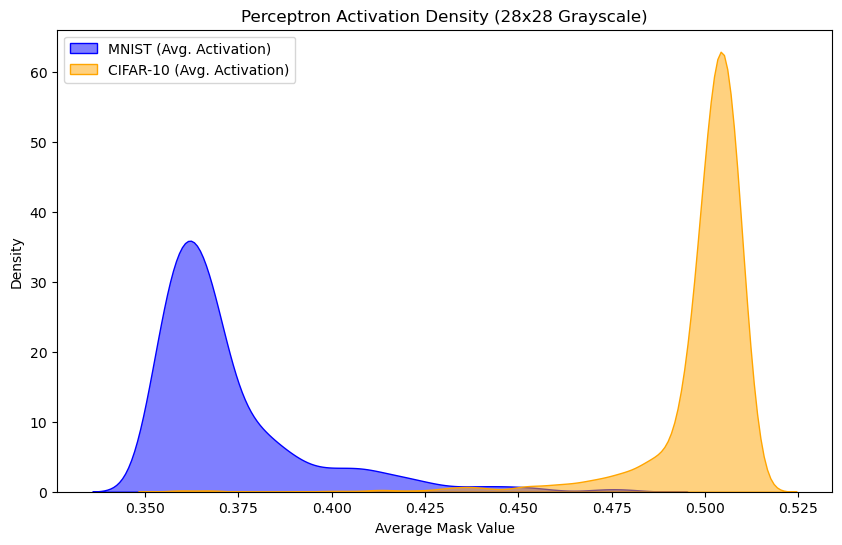

In [12]:
analyze_gate_behavior(model, test_loader_mnist, test_loader_cifar)

In [13]:
def visualize_latent_space(model, loader_mnist, loader_cifar, num_samples=500):
    model.eval()
    features = []
    domain_labels = [] 
    
    with torch.no_grad():
        count = 0
        for data, target in loader_mnist:
            if count >= num_samples: break
            data = data.to(device)
            x = model.gate1(model.bn1(model.conv1(data)))
            x = model.gate2(model.bn2(model.conv2(x)))
            x = model.pool1(x)
            x = model.gate3(model.bn3(model.conv3(x)))
            x = model.gate4(model.bn4(model.conv4(x)))
            x = model.pool2(x)
            x = model.gate5(model.bn5(model.conv5(x)))
            x = model.pool3(x)
            x = x.view(-1, model.flatten_dim)
            x = F.relu(model.bn_fc1(model.fc1(x)))
            feat = F.relu(model.bn_fc2(model.fc2(x)))
            features.extend(feat.cpu().numpy())
            domain_labels.extend(["MNIST"] * data.size(0))
            count += data.size(0)

        count = 0
        for data, target in loader_cifar:
            if count >= num_samples: break
            data = data.to(device)
            x = model.gate1(model.bn1(model.conv1(data)))
            x = model.gate2(model.bn2(model.conv2(x)))
            x = model.pool1(x)
            x = model.gate3(model.bn3(model.conv3(x)))
            x = model.gate4(model.bn4(model.conv4(x)))
            x = model.pool2(x)
            x = model.gate5(model.bn5(model.conv5(x)))
            x = model.pool3(x)
            x = x.view(-1, model.flatten_dim)
            x = F.relu(model.bn_fc1(model.fc1(x)))
            feat = F.relu(model.bn_fc2(model.fc2(x)))
            features.extend(feat.cpu().numpy())
            domain_labels.extend(["CIFAR"] * data.size(0))
            count += data.size(0)

    tsne = TSNE(n_components=2, random_state=42)
    features_2d = tsne.fit_transform(np.array(features))
    df = pd.DataFrame({'x': features_2d[:, 0], 'y': features_2d[:, 1], 'Domain': domain_labels})
    
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=df, x='x', y='y', hue='Domain', alpha=0.7)
    plt.title("Latent Space - t-SNE")
    plt.show()


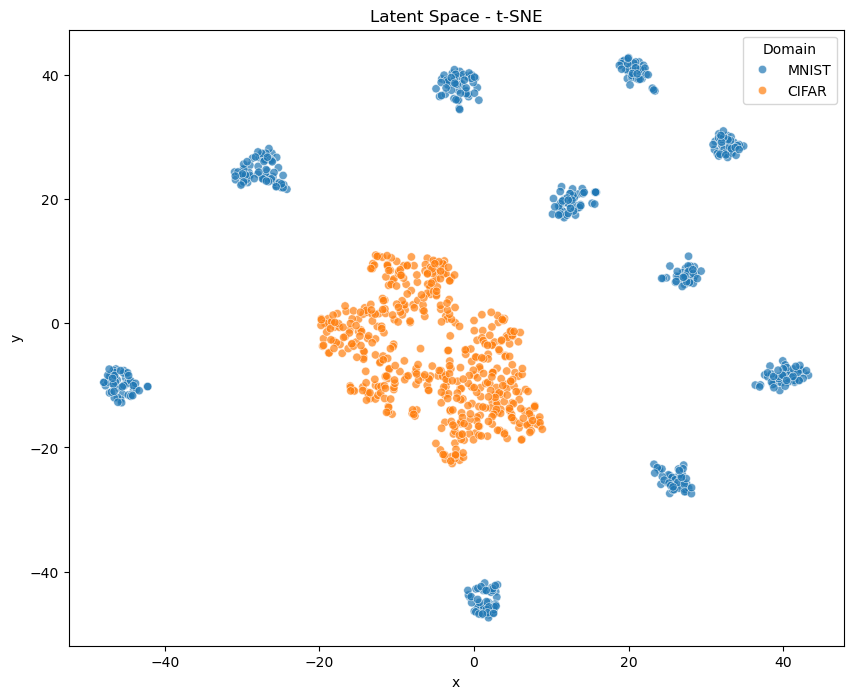

In [14]:
visualize_latent_space(model, test_loader_mnist, test_loader_cifar)

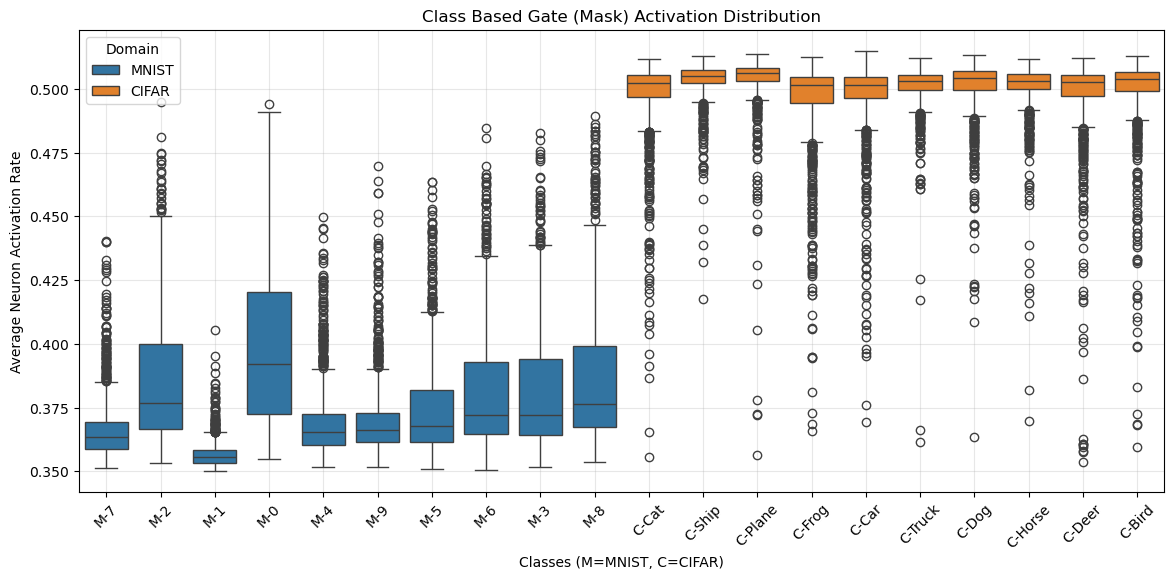

In [15]:
def analyze_gate_per_class(model, loader_mnist, loader_cifar, class_names):
    model.eval()
    class_gate_values = {name: [] for name in class_names}
    
    with torch.no_grad():
        for data, target in loader_mnist:
            data = data.to(device)
            _ = model(data)
            mask_means = model.gate1.saved_mask.mean(dim=(1, 2, 3)).cpu().numpy()
            for i, label in enumerate(target):
                class_name = f"MNIST-{label.item()}"
                pass 
            
    data_list = []
    
    with torch.no_grad():
        # MNIST Döngüsü
        for data, target in loader_mnist:
            data = data.to(device)
            _ = model(data)
            mask_means = model.gate1.saved_mask.mean(dim=(1, 2, 3)).cpu().numpy()
            for i, label in enumerate(target):
                data_list.append({
                    'Class': f"M-{label.item()}", 
                    'Domain': 'MNIST', 
                    'GateValue': mask_means[i]
                })
                
        # CIFAR Döngüsü
        cifar_labels = ['Plane', 'Car', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
        for data, target in loader_cifar:
            data = data.to(device)
            _ = model(data)
            mask_means = model.gate1.saved_mask.mean(dim=(1, 2, 3)).cpu().numpy()
            for i, label in enumerate(target):
                data_list.append({
                    'Class': f"C-{cifar_labels[label.item()]}", 
                    'Domain': 'CIFAR', 
                    'GateValue': mask_means[i]
                })

    df = pd.DataFrame(data_list)
    
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=df, x='Class', y='GateValue', hue='Domain', dodge=False)
    plt.xticks(rotation=45)
    plt.title("Class Based Gate (Mask) Activation Distribution")
    plt.xlabel("Classes (M=MNIST, C=CIFAR)")
    plt.ylabel("Average Neuron Activation Rate")
    plt.grid(True, alpha=0.3)
    plt.show()

analyze_gate_per_class(model, test_loader_mnist, test_loader_cifar, class_names=[])


--- MNIST İçin En 'Kararsız' (Ambiguous) Örnekler ---


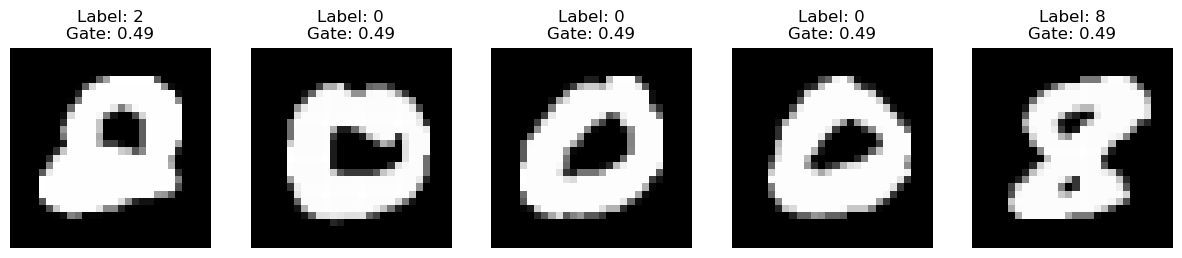


--- CIFAR İçin En 'Kararsız' (Ambiguous) Örnekler ---


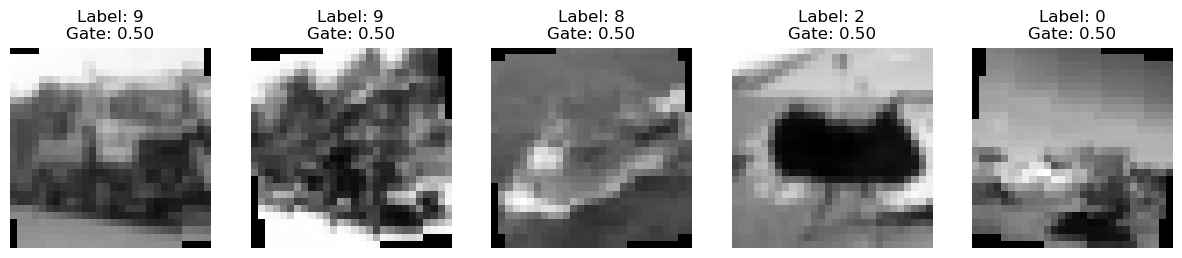

In [16]:
def visualize_ambiguous_samples(model, loader, domain_name, num_samples=5):
    model.eval()
    ambiguous_samples = [] 
    
    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            _ = model(data)
            mask_means = model.gate1.saved_mask.mean(dim=(1, 2, 3)).cpu()
            
            for i, val in enumerate(mask_means):
                # 0.5'e olan uzaklık (ne kadar küçükse o kadar kararsız)
                uncertainty = abs(val.item() - 0.5) 
                ambiguous_samples.append((uncertainty, data[i].cpu(), target[i].item(), val.item()))
    
    # En kararsızları (0.5'e en yakınları) sıralıyor
    ambiguous_samples.sort(key=lambda x: x[0])
    
    print(f"\n--- {domain_name} İçin En 'Kararsız' (Ambiguous) Örnekler ---")
    plt.figure(figsize=(15, 3))
    for i in range(num_samples):
        uncertainty, img_tensor, label, gate_val = ambiguous_samples[i]
        plt.subplot(1, num_samples, i+1)
        img = img_tensor.squeeze().numpy()
        plt.imshow(img, cmap='gray')
        plt.title(f"Label: {label}\nGate: {gate_val:.2f}")
        plt.axis('off')
    plt.show()

visualize_ambiguous_samples(model, test_loader_mnist, "MNIST")
visualize_ambiguous_samples(model, test_loader_cifar, "CIFAR")

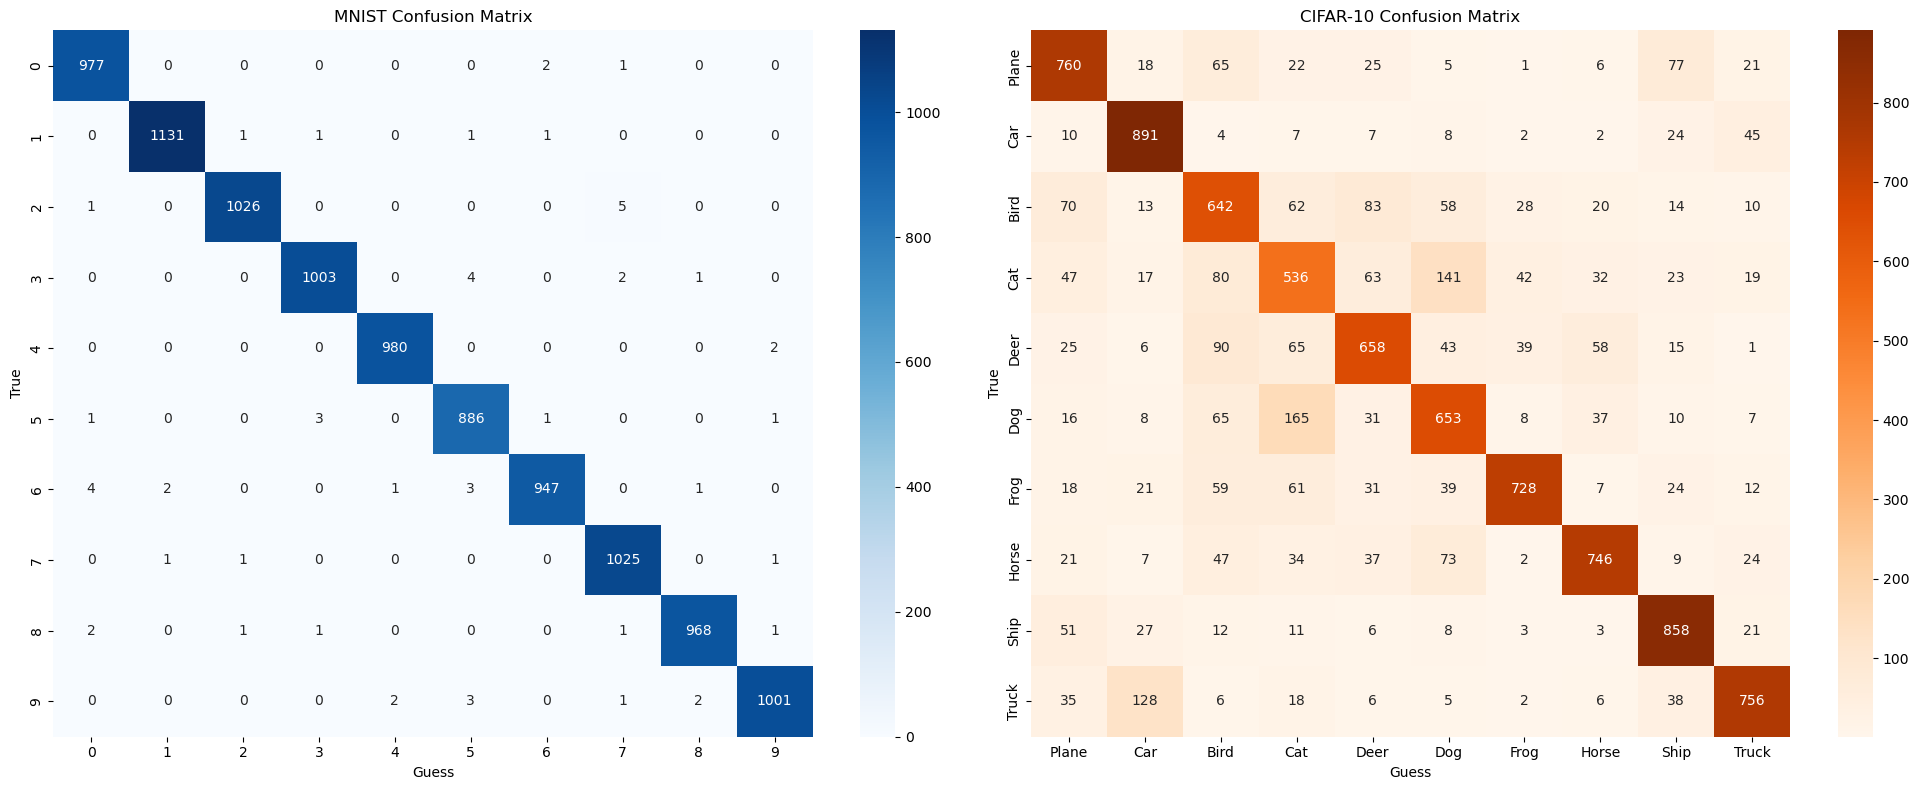

In [17]:
def plot_dual_confusion_matrix(model, loader_mnist, loader_cifar):
    model.eval()
    
    mnist_classes = [str(i) for i in range(10)]
    cifar_classes = ['Plane', 'Car', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
    
    _, _, labels_m, preds_m = evaluate_domain(model, loader_mnist, "MNIST")
    cm_m = confusion_matrix(labels_m, preds_m)
    
    _, _, labels_c, preds_c = evaluate_domain(model, loader_cifar, "CIFAR")
    cm_c = confusion_matrix(labels_c, preds_c)
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    sns.heatmap(cm_m, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
                xticklabels=mnist_classes, yticklabels=mnist_classes)
    axes[0].set_title("MNIST Confusion Matrix")
    axes[0].set_ylabel("True")
    axes[0].set_xlabel("Guess")

    sns.heatmap(cm_c, annot=True, fmt='d', cmap='Oranges', ax=axes[1], 
                xticklabels=cifar_classes, yticklabels=cifar_classes)
    axes[1].set_title("CIFAR-10 Confusion Matrix")
    axes[1].set_ylabel("True")
    axes[1].set_xlabel("Guess")
    
    plt.tight_layout()
    plt.show()

plot_dual_confusion_matrix(model, test_loader_mnist, test_loader_cifar)

Gate Ayrışma Analizi Başlıyor (5 Katman)...

QUANTITATIVE DOMAIN SEPARATION RESULTS
 Gate  MNIST Avg. Activation  CIFAR Avg. Activation  Separation Score
gate1                 0.3719                 0.4996            0.1277
gate2                 0.5135                 0.5305            0.0170
gate3                 0.3519                 0.4885            0.1366
gate4                 0.4783                 0.5791            0.1008
gate5                 0.3331                 0.6025            0.2693
----------------------------------------------------------------------
YORUM: Score > 0.1 farkın başladığını, Score > 0.5 çok güçlü ayrışmayı gösterir.


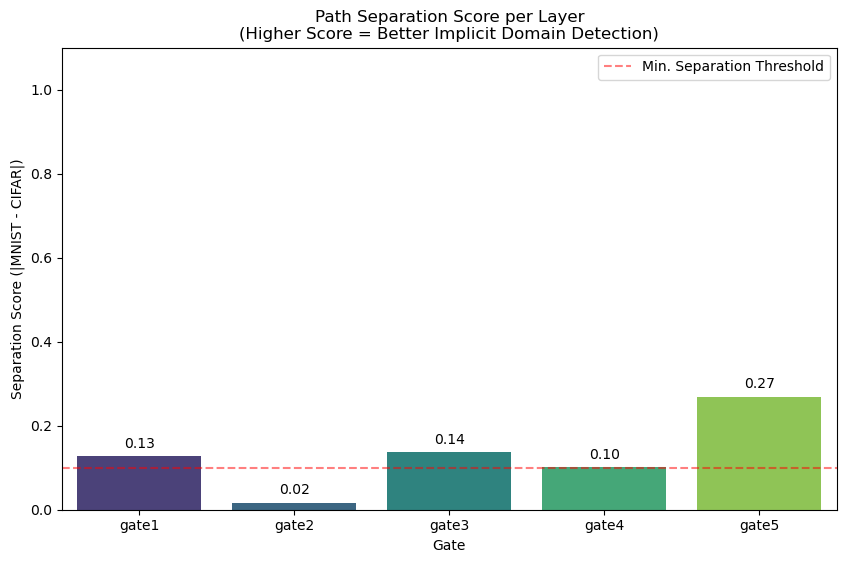

In [18]:
def calculate_quantified_separation(model, loader_mnist, loader_cifar, device):

    model.eval()
    gate_layers = ['gate1', 'gate2', 'gate3', 'gate4', 'gate5']
    results = []
    
    print(f"Gate Ayrışma Analizi Başlıyor ({len(gate_layers)} Katman)...")
    
    for gate_name in gate_layers:
        mnist_vals = []
        with torch.no_grad():
            for i, (data, _) in enumerate(loader_mnist):
                if i >= 10: break 
                data = data.to(device)
                _ = model(data)
                
                if hasattr(model, gate_name):
                    gate_module = getattr(model, gate_name)
                    if gate_module.saved_mask is not None:
                        mnist_vals.append(gate_module.saved_mask.mean().item())
        
        mnist_mean = np.mean(mnist_vals) if mnist_vals else 0

        cifar_vals = []
        with torch.no_grad():
            for i, (data, _) in enumerate(loader_cifar):
                if i >= 10: break
                data = data.to(device)
                _ = model(data)
                
                if hasattr(model, gate_name):
                    gate_module = getattr(model, gate_name)
                    if gate_module.saved_mask is not None:
                        cifar_vals.append(gate_module.saved_mask.mean().item())
                
        cifar_mean = np.mean(cifar_vals) if cifar_vals else 0
        
        separation_score = abs(mnist_mean - cifar_mean)
        
        results.append({
            'Gate': gate_name,
            'MNIST Avg. Activation': mnist_mean,
            'CIFAR Avg. Activation': cifar_mean,
            'Separation Score': separation_score
        })

    df_res = pd.DataFrame(results)
    
    print("\n" + "="*70)
    print("QUANTITATIVE DOMAIN SEPARATION RESULTS")
    print("="*70)
    print(df_res.to_string(index=False, float_format="%.4f"))
    print("-" * 70)
    print("YORUM: Score > 0.1 farkın başladığını, Score > 0.5 çok güçlü ayrışmayı gösterir.")
    print("="*70)
    
    plt.figure(figsize=(10, 6))
    barplot = sns.barplot(data=df_res, x='Gate', y='Separation Score', hue='Gate', palette='viridis', legend=False)
    
    for p in barplot.patches:
        barplot.annotate(format(p.get_height(), '.2f'), 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha = 'center', va = 'center', 
                         xytext = (0, 9), 
                         textcoords = 'offset points')
                         
    plt.axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='Min. Separation Threshold')
    plt.title('Path Separation Score per Layer\n(Higher Score = Better Implicit Domain Detection)')
    plt.ylabel('Separation Score (|MNIST - CIFAR|)')
    plt.ylim(0, 1.1)
    plt.legend()
    plt.show()
    
    return df_res

df_scores = calculate_quantified_separation(model, test_loader_mnist, test_loader_cifar, device)